Archivo cargado exitosamente.
Total de muestras recolectadas: 39300
Duración de la grabación: 39.30 segundos


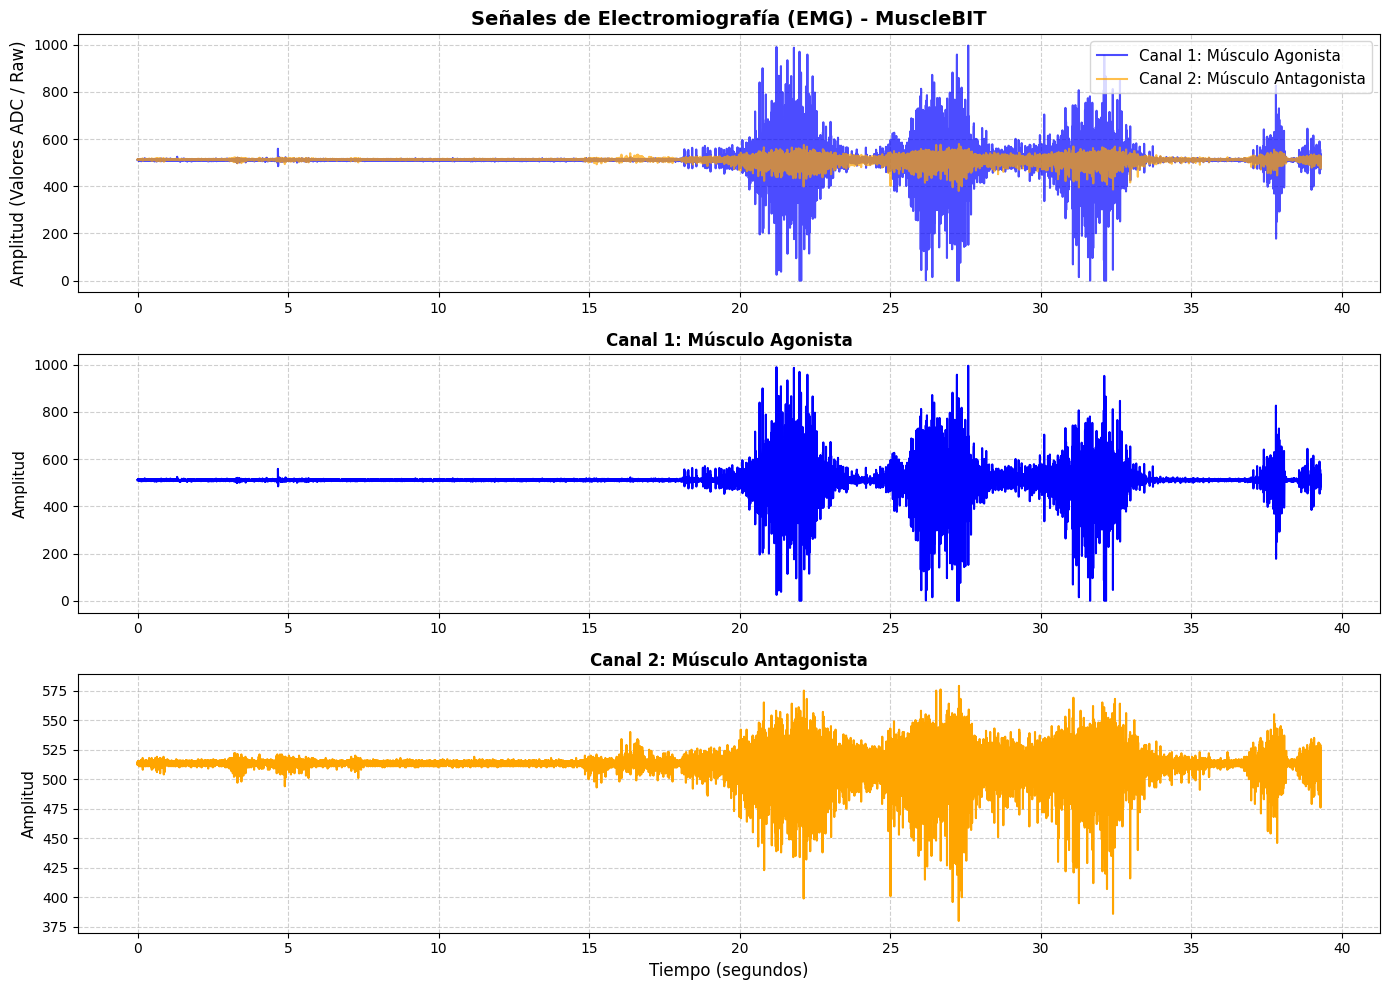

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

nombre_archivo = "Prueba 2 Juan Y balance pierna izquierda.txt"
frecuencia_muestreo = 1000  # 1000 Hz

datos = pd.read_csv(nombre_archivo, sep='\t', comment='#', header=None)
datos = datos.dropna(axis=1, how='all')

columnas_totales = datos.shape[1]
datos.columns = [f"Col_{i}" for i in range(columnas_totales - 2)] + ["Canal_1", "Canal_2"]

# Extraer las señales
señal_agonista = datos["Canal_1"].values
señal_antagonista = datos["Canal_2"].values

# Crear el vector de tiempo en segundos
num_muestras = len(datos)
tiempo = np.arange(num_muestras) / frecuencia_muestreo

print(f"Archivo cargado exitosamente.")
print(f"Total de muestras recolectadas: {num_muestras}")
print(f"Duración de la grabación: {tiempo[-1]:.2f} segundos")

plt.figure(figsize=(14, 10))

# grafica 1 ambas señales superpuestas
plt.subplot(3, 1, 1)
plt.plot(tiempo, señal_agonista, label='Canal 1: Músculo Agonista', color='blue', alpha=0.7)
plt.plot(tiempo, señal_antagonista, label='Canal 2: Músculo Antagonista', color='orange', alpha=0.7)
plt.title('Señales de Electromiografía (EMG) - MuscleBIT', fontsize=14, fontweight='bold')
plt.ylabel('Amplitud (Valores ADC / Raw)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', fontsize=11)

# grafica 2 musculo Agonista -Canal 1
plt.subplot(3, 1, 2)
plt.plot(tiempo, señal_agonista, color='blue')
plt.title('Canal 1: Músculo Agonista', fontsize=12, fontweight='bold')
plt.ylabel('Amplitud', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# grafica 3 musculo Antagonista-Canal 2
plt.subplot(3, 1, 3)
plt.plot(tiempo, señal_antagonista, color='orange')
plt.title('Canal 2: Músculo Antagonista', fontsize=12, fontweight='bold')
plt.xlabel('Tiempo (segundos)', fontsize=12)
plt.ylabel('Amplitud', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Configuración de procesamiento lista.
Procesamiento completado con éxito


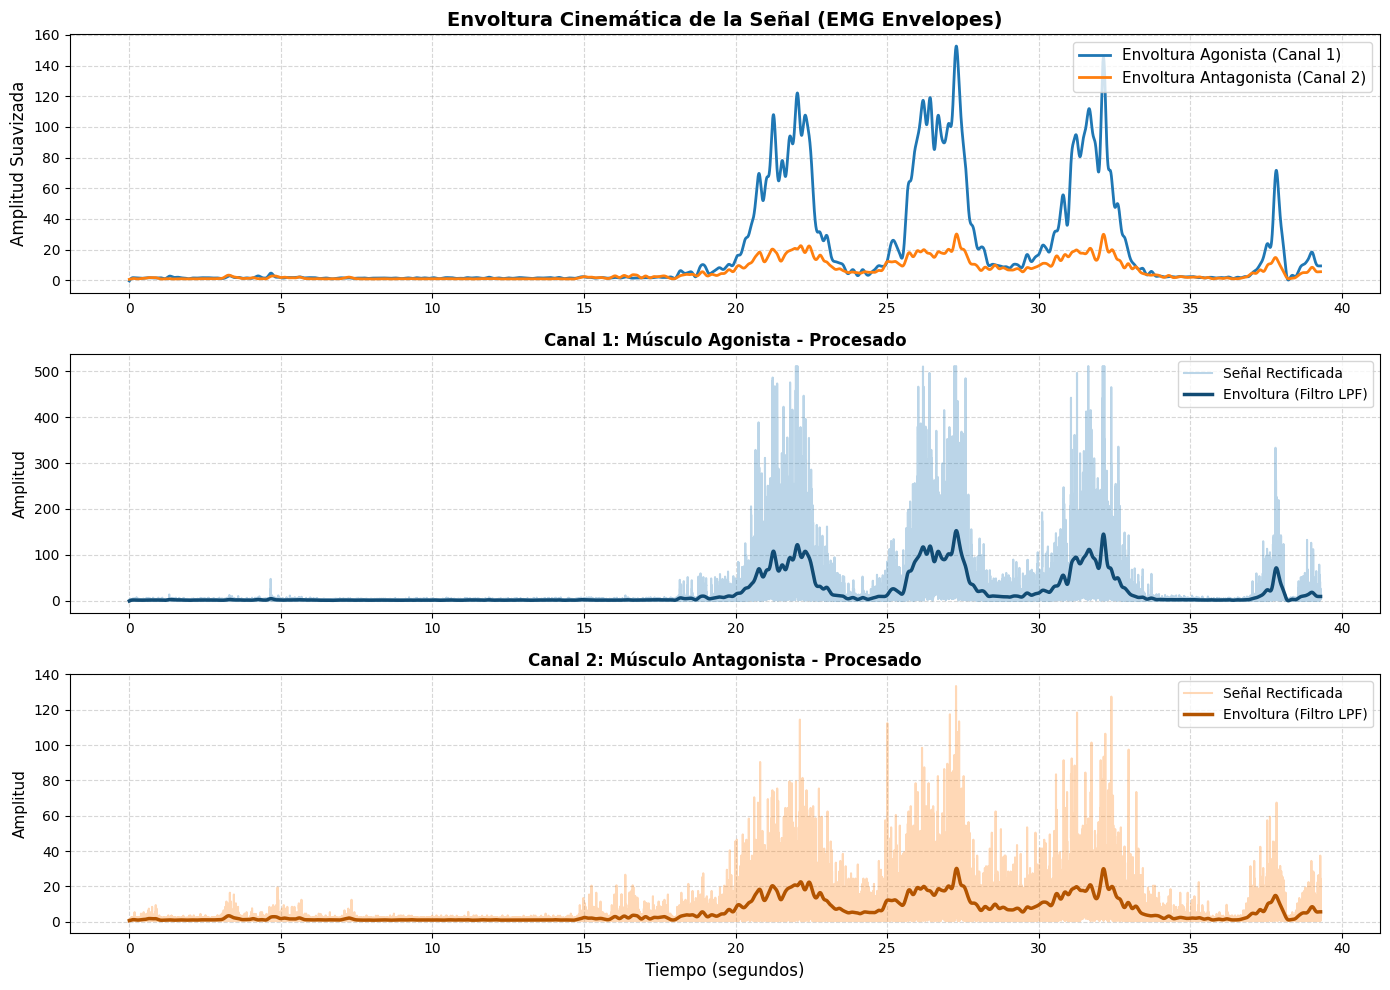

In [3]:
# parametros del filtro para obtener la envoltura de la señal
# la frecuencia de corte se encuentra entre 3 - 5 hz
frecuencia_corte = 4.0
orden_filtro = 4

print("Configuración de procesamiento lista.")

#cargar archivo
datos = pd.read_csv(nombre_archivo, sep='\t', comment='#', header=None)
datos = datos.dropna(axis=1, how='all')

#extraccion de las señales de los musculos
señal_agonista_raw = datos.iloc[:, -2].values
señal_antagonista_raw = datos.iloc[:, -1].values

#vector de tiempo
tiempo = np.arange(len(datos)) / frecuencia_muestreo

# filtro Pasa-Bajos Butterworth
def filtro_pasa_bajos(data, cutoff, fs, order=5):
    nyq = 0.5 * fs  # frecuencia de Nyquist
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

#Procesar las señales: Centrar -> Rectificar -> Filtrar
#Canal 1 - Agonista
agonista_centrada = señal_agonista_raw - np.mean(señal_agonista_raw)
agonista_rectificada = np.abs(agonista_centrada)
envoltura_agonista = filtro_pasa_bajos(agonista_rectificada, frecuencia_corte, frecuencia_muestreo, orden_filtro)

#Canal 2 - Antagonista
antagonista_centrada = señal_antagonista_raw - np.mean(señal_antagonista_raw)
antagonista_rectificada = np.abs(antagonista_centrada)
envoltura_antagonista = filtro_pasa_bajos(antagonista_rectificada, frecuencia_corte, frecuencia_muestreo, orden_filtro)

print("Procesamiento completado con éxito")

#Graficar

plt.figure(figsize=(14, 10))

#grafica 1 envolturas superpuestas
plt.subplot(3, 1, 1)
plt.plot(tiempo, envoltura_agonista, label='Envoltura Agonista (Canal 1)', color='#1f77b4', linewidth=2)
plt.plot(tiempo, envoltura_antagonista, label='Envoltura Antagonista (Canal 2)', color='#ff7f0e', linewidth=2)
plt.title('Envoltura Cinemática de la Señal (EMG Envelopes)', fontsize=14, fontweight='bold')
plt.ylabel('Amplitud Suavizada', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=11)

# grafico 2 musculo agonista (Señal limpia + Envoltura)
plt.subplot(3, 1, 2)
plt.plot(tiempo, agonista_rectificada, color='#1f77b4', alpha=0.3, label='Señal Rectificada')
plt.plot(tiempo, envoltura_agonista, color='#114b73', linewidth=2.5, label='Envoltura (Filtro LPF)')
plt.title('Canal 1: Músculo Agonista - Procesado', fontsize=12, fontweight='bold')
plt.ylabel('Amplitud', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

# grafico 3 musculo antagonista (Señal limpia + Envoltura)
plt.subplot(3, 1, 3)
plt.plot(tiempo, antagonista_rectificada, color='#ff7f0e', alpha=0.3, label='Señal Rectificada')
plt.plot(tiempo, envoltura_antagonista, color='#b35400', linewidth=2.5, label='Envoltura (Filtro LPF)')
plt.title('Canal 2: Músculo Antagonista - Procesado', fontsize=12, fontweight='bold')
plt.xlabel('Tiempo (segundos)', fontsize=12)
plt.ylabel('Amplitud', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

/tmp/ipykernel_6413/402738828.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_interseccion = np.trapz(curva_interseccion, tiempo)


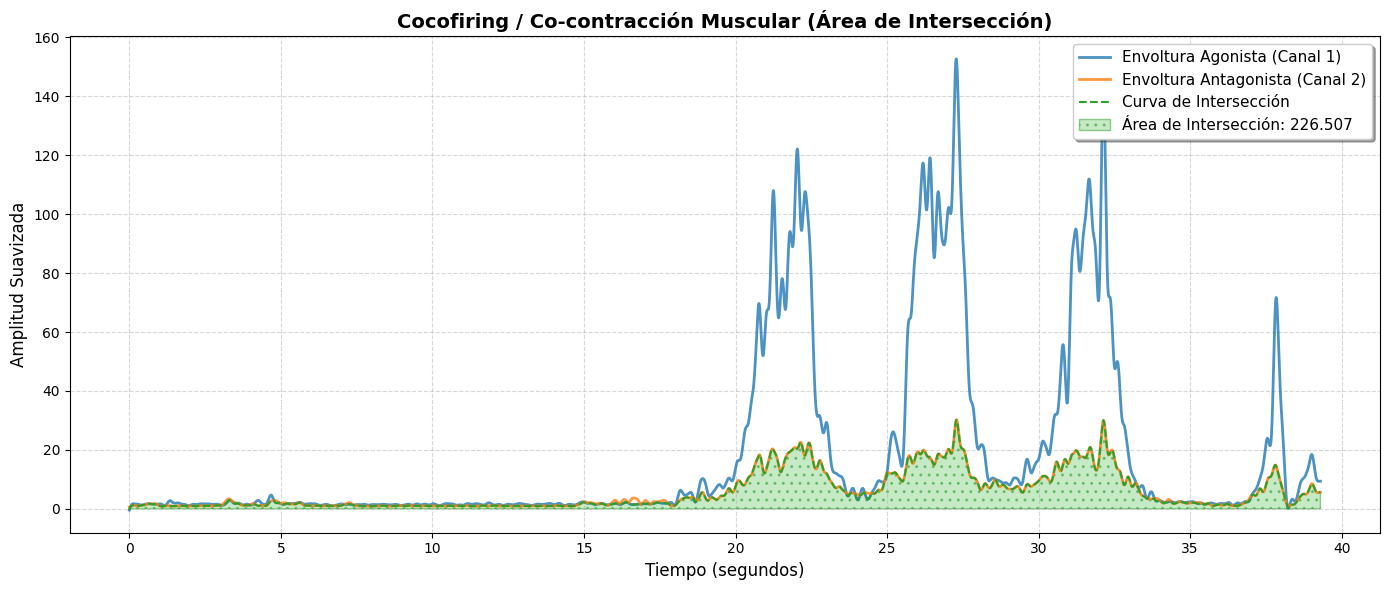

In [4]:
# Calcular la curva de interseccion
curva_interseccion = np.minimum(envoltura_agonista, envoltura_antagonista)

# Calcular el área numérica bajo la curva de intersección usando la regla del trapecio
area_interseccion = np.trapz(curva_interseccion, tiempo)

#grafico
plt.figure(figsize=(14, 6))

# envolturas de las señales originales
plt.plot(tiempo, envoltura_agonista, label='Envoltura Agonista (Canal 1)', color='#1f77b4', linewidth=2, alpha=0.8)
plt.plot(tiempo, envoltura_antagonista, label='Envoltura Antagonista (Canal 2)', color='#ff7f0e', linewidth=2, alpha=0.8)

# Dibujar la curva de la intersección
plt.plot(tiempo, curva_interseccion, label='Curva de Intersección', color='#2ca02c', linewidth=1.5, linestyle='--')

# sombrear el área debajo de la curva de intersección
plt.fill_between(tiempo, 0, curva_interseccion,
                 facecolor='#8ed68e',
                 edgecolor='#2ca02c',
                 hatch='..',
                 alpha=0.5,
                 label=f'Área de Intersección: {area_interseccion:.3f}')

#grafica
plt.title('Cocofiring / Co-contracción Muscular (Área de Intersección)', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo (segundos)', fontsize=12)
plt.ylabel('Amplitud Suavizada', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

#leyenda
plt.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)

plt.tight_layout()
plt.show()

/tmp/ipykernel_6413/1219532360.py:2: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_agonista = np.trapz(envoltura_agonista, tiempo)
/tmp/ipykernel_6413/1219532360.py:3: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_antagonista = np.trapz(envoltura_antagonista, tiempo)


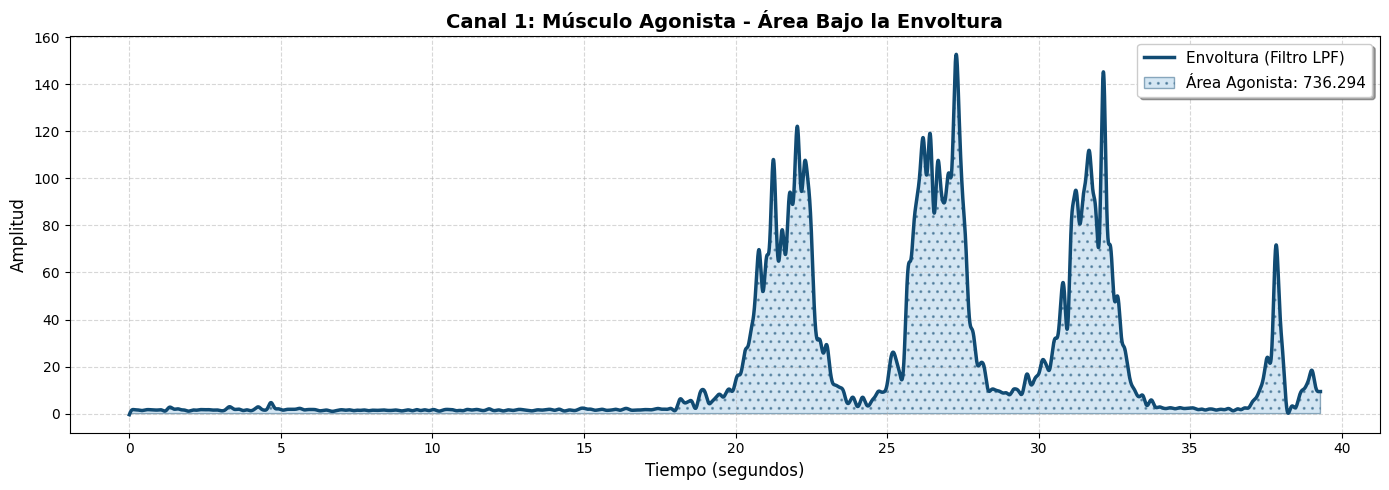

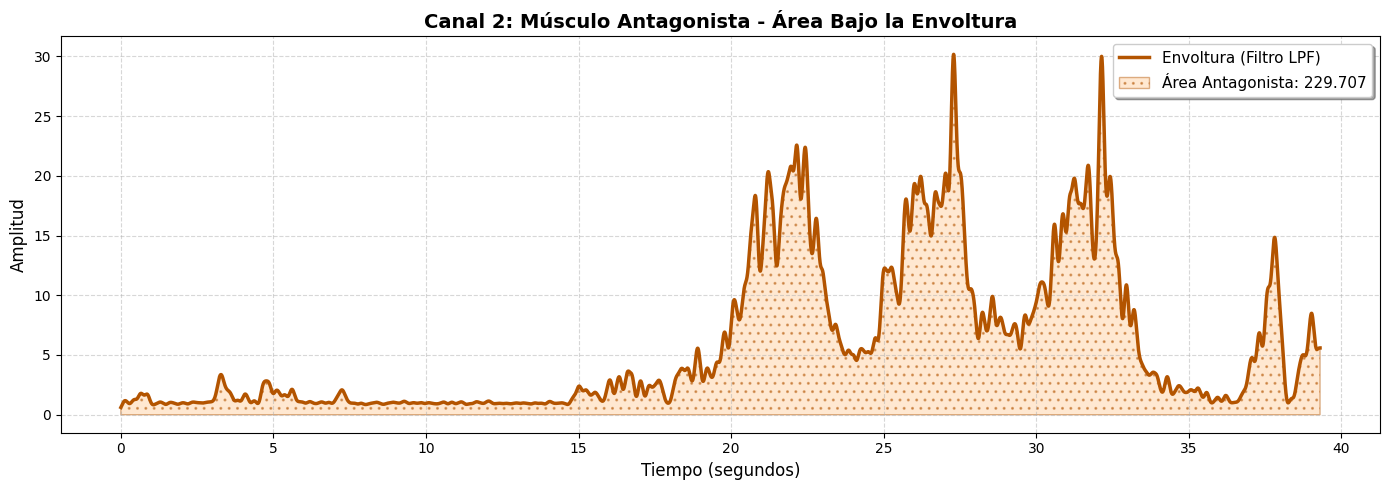

In [5]:
#Procedimiento para la curva y area para las señales de los musculos agonista y antagonista
area_agonista = np.trapz(envoltura_agonista, tiempo)
area_antagonista = np.trapz(envoltura_antagonista, tiempo)

#grafica musculo agonista
plt.figure(figsize=(14, 5))

#señal de la envoltura
plt.plot(tiempo, envoltura_agonista, color='#114b73', linewidth=2.5, label='Envoltura (Filtro LPF)')

#area bajo la curva
plt.fill_between(tiempo, 0, envoltura_agonista,
                 facecolor='#a1c9e5',
                 edgecolor='#114b73',
                 hatch='..',
                 alpha=0.45,
                 label=f'Área Agonista: {area_agonista:.3f}')

plt.title('Canal 1: Músculo Agonista - Área Bajo la Envoltura', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo (segundos)', fontsize=12)
plt.ylabel('Amplitud', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)
plt.tight_layout()
plt.show()


#grafica musculo antagonista
plt.figure(figsize=(14, 5))

plt.plot(tiempo, envoltura_antagonista, color='#b35400', linewidth=2.5, label='Envoltura (Filtro LPF)')

plt.fill_between(tiempo, 0, envoltura_antagonista,
                 facecolor='#ffcc99',
                 edgecolor='#b35400',
                 hatch='..',
                 alpha=0.45,
                 label=f'Área Antagonista: {area_antagonista:.3f}')

plt.title('Canal 2: Músculo Antagonista - Área Bajo la Envoltura', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo (segundos)', fontsize=12)
plt.ylabel('Amplitud', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)
plt.tight_layout()
plt.show()

 (\(CCI\)) para este registro es de \(46.90\%\).